# 22. 量化进阶：per-group INT4 · GPTQ 列重排 · INT4 vs INT8 实测

第 14 讲做了 **INT8 对称量化**（per-tensor / per-channel）。本讲回答生产必问的三件事：

1. **per-group 是什么**：不按整层、不按整行，把权重切成小组各自定 scale——
   **粒度越细误差越小，但 scale 存储开销越大**（找平衡点是工程活）
2. **GPTQ 凭什么比直接舍入好**：把每个权重的量化误差**沿 Hessian 信息量摊到未量化列**补偿，
   并做**列重排**（最敏感列先量化）——本讲完整手搓并三方对比 RTN / 无重排 / 列重排
3. **INT4 到底值不值**：同一层权重、同一输入，INT8 vs INT4 的输出 MSE、显存、速度一次测清

> 第 14 讲内容只留"核心回顾"（第 0 节），完整实验见 `14_quantization.ipynb`。


## 0. 第 14 讲回顾：INT8 对称量化（本讲前置）

核心公式（$b=8$，范围 $[-127,127]$）：

$$s=\frac{\max|x|}{2^{b-1}-1},\qquad q=\mathrm{clip}\big(\mathrm{round}(w/s),\ -127,\ 127\big),\qquad \hat w=q\cdot s$$

- **per-tensor**：整个矩阵共用一个 $s$；**per-channel**：每个输出行单独一个 $s$（主流做法）
- 第 14 讲结论：per-channel 误差 < per-tensor（本小节复现）；端到端小网络量化后 MSE < 0.1；fp64→int8 显存省 8 倍
- 第 14 讲还对比了生产方案：GPTQ / AWQ / GGUF / KV cache 量化（详见 `14_quantization.ipynb` 第 4 节）


In [2]:
import numpy as np

# ---- 第 14 讲核心回顾：INT8 对称量化（per-tensor / per-channel）----
def quantize_int8(W, per_channel=False):
    """INT8 对称量化：per_channel=False 整个矩阵一个 scale；True 每输出行一个 scale。"""
    if not per_channel:
        s = np.abs(W).max() / 127.0
        q = np.clip(np.round(W / s), -127, 127).astype(np.int8)
        return q, s
    s = np.abs(W).max(axis=1, keepdims=True) / 127.0       # 每行（每个输出通道）一个 scale
    q = np.clip(np.round(W / s), -127, 127).astype(np.int8)
    return q, s

def dequantize(q, s):
    """反量化：hat_w = q * s（s 广播）。"""
    return q.astype(np.float64) * s

def rel_err(W, W_hat):
    """相对误差 ||W - Ŵ|| / ||W||（第 14 讲的度量）。"""
    return float(np.linalg.norm(W - W_hat) / np.linalg.norm(W))

rng = np.random.default_rng(0)
W8 = rng.standard_normal((64, 64))                          # 模拟一个线性层权重（正态分布）

e_t = rel_err(W8, dequantize(*quantize_int8(W8, per_channel=False)))
e_c = rel_err(W8, dequantize(*quantize_int8(W8, per_channel=True)))
print(f'per-tensor int8 : 相对误差 = {e_t:.4f}')
print(f'per-channel int8: 相对误差 = {e_c:.4f}')
assert e_c < e_t
print('per-channel 误差 < per-tensor  ->  PASS（与第 14 讲结论一致）')


per-tensor int8 : 相对误差 = 0.0089
per-channel int8: 相对误差 = 0.0058
per-channel 误差 < per-tensor  ->  PASS（与第 14 讲结论一致）


## 1. 公式：per-group 对称量化 · RTN · GPTQ

**per-group 对称量化**（组大小 $g$，$b$ bit，整数范围 $[-2^{b-1}, 2^{b-1}-1]$）：

每组（$g$ 个权重）一个 scale：$s_j = \dfrac{\max_i|w_{j,i}|}{2^{b-1}-1}$，　$q = \operatorname{clamp}(\lfloor w/s\rfloor, \dots)$，　$\hat w = q\cdot s$

**RTN（round to nearest）**：逐权重独立舍入——最简单，误差无补偿。

**GPTQ 核心方程**（Frantar et al. 2022/2023）：设对象为 $\min_{\hat W}\lVert XW^\top - X\hat W^\top\rVert^2_F$，
$H = 2XX^\top$ 为输入相关二阶信息。逐列量化第 $i$ 列产生误差 $\mathbf e_i$ 后，对**未量化列** $j>i$ 补偿：

$$\delta_j = -\frac{(H^{-1})_{i,j}}{(H^{-1})_{i,i}}\,\mathbf e_i$$

直觉：把"量化这一列带来的损失"按照 Hessian 的耦合强度预先摊到还没量化的列上，让它们后面的量化去吸收。
再加**列重排**（按 $H^{-1}$ 对角线降序先量化最敏感列），序贯误差就不累积。


In [4]:
import numpy as np

def quantize(w, scale):
    """对称量化 + 反量化：w -> q（整型）与 w_hat（重建）。"""
    q = np.clip(np.round(w / scale), -8, 7)
    return q, q * scale

def quant_per_tensor(W, bits=4):
    scale = np.abs(W).max() / (2 ** (bits - 1) - 1)
    return quantize(W, scale)

def quant_per_channel(W, bits=4):
    scale = np.abs(W).max(axis=1, keepdims=True) / (2 ** (bits - 1) - 1)
    return quantize(W, scale)

def quant_per_group(W, g, bits=4):
    """per-group：把 [out, in] 沿最后一维切成组 [out, in//g, g]（不足补零处不量化）。"""
    out, inn = W.shape
    Wr = W.reshape(out, inn // g, g)
    scale = np.abs(Wr).max(axis=2, keepdims=True) / (2 ** (bits - 1) - 1)
    scale = np.where(scale < 1e-12, 1.0, scale)      # 全零组防除零
    q = np.clip(np.round(Wr / scale), -8, 7)
    return q.reshape(out, inn), (q * scale).reshape(out, inn)

np.random.seed(0)
W = np.random.randn(64, 64) * 0.3                    # 模拟一层权重（含负值）

_, w_t = quant_per_tensor(W, 4)
_, w_c = quant_per_channel(W, 4)
for g in (8, 16, 32, 64):
    _, w_g = quant_per_group(W, g, 4)
    err = np.abs(w_g - W).mean()
    print(f'per-group g={g:3d}  INT4 平均绝对误差 = {err:.5f}')
print(f'per-channel  INT4 平均绝对误差 = {np.abs(w_c - W).mean():.5f}')
print(f'per-tensor   INT4 平均绝对误差 = {np.abs(w_t - W).mean():.5f}')
err_g32 = np.abs(quant_per_group(W, 32, 4)[1] - W).mean()
assert err_g32 < np.abs(w_c - W).mean() < np.abs(w_t - W).mean()
print('误差排序：per-tensor > per-channel > per-group（粒度越细越准） ->  PASS')


per-group g=  8  INT4 平均绝对误差 = 0.01653
per-group g= 16  INT4 平均绝对误差 = 0.02061
per-group g= 32  INT4 平均绝对误差 = 0.02399
per-group g= 64  INT4 平均绝对误差 = 0.02698
per-channel  INT4 平均绝对误差 = 0.02698
per-tensor   INT4 平均绝对误差 = 0.04033
误差排序：per-tensor > per-channel > per-group（粒度越细越准） ->  PASS


In [5]:
import torch
import torch.nn as nn

torch.manual_seed(0)
# 端到端：量化一层真实 Linear 后前向，量化输出与原始输出的差距
layer = nn.Linear(64, 64, dtype=torch.float64)
X = torch.randn(96, 64, dtype=torch.float64)
with torch.no_grad():
    y0 = layer(X)

Wn = layer.weight.detach().numpy()
def layer_out(Wq):
    with torch.no_grad():
        return (X @ torch.tensor(Wq, dtype=torch.float64).T + layer.bias.detach())

mse = []
for g in (4, 8, 16, 32, 64):
    _, wq = quant_per_group(Wn, g, 4)
    mse.append(float(((layer_out(wq) - y0) ** 2).mean()))
_, wq_c = quant_per_channel(Wn, 4)
mse_c = float(((layer_out(wq_c) - y0) ** 2).mean())
for g, m in zip((4, 8, 16, 32, 64), mse):
    print(f'INT4 group={g:4d}  输出 MSE = {m:.2e}')
print(f'INT4 per-channel    输出 MSE = {mse_c:.2e}')
assert mse[-1] <= mse_c * 1.01, 'g=64（每行一组）应等价于 per-channel'
assert all(mse[i] <= mse[i + 1] * 1.01 for i in range(len(mse) - 1))
print('组越小误差越小；g=64 与 per-channel 等价 ->  PASS')


INT4 group=   4  输出 MSE = 8.62e-04
INT4 group=   8  输出 MSE = 1.21e-03
INT4 group=  16  输出 MSE = 1.40e-03
INT4 group=  32  输出 MSE = 1.53e-03
INT4 group=  64  输出 MSE = 1.60e-03
INT4 per-channel    输出 MSE = 1.60e-03
组越小误差越小；g=64 与 per-channel 等价 ->  PASS


### 粒度-误差曲线

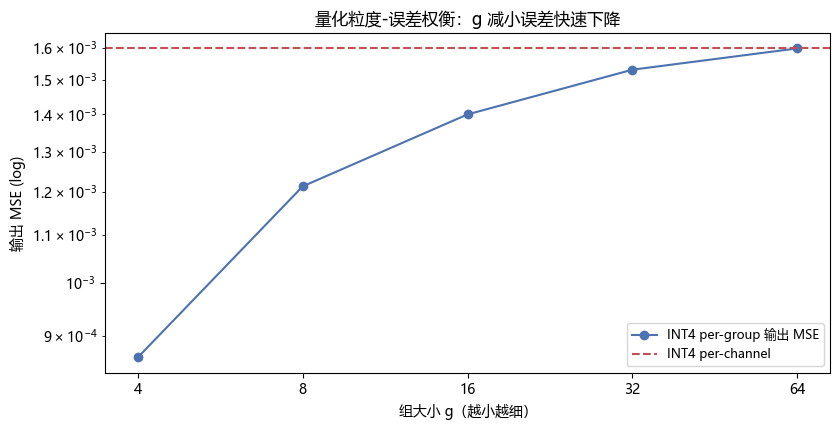

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(8.5, 4.4))
gs = [4, 8, 16, 32, 64]
ax.plot(gs, mse, 'o-', color='#4C72B0', label='INT4 per-group 输出 MSE')
ax.axhline(mse_c, color='#C44E52', ls='--', label='INT4 per-channel')
ax.set_xscale('log', base=2)
ax.set_xticks(gs); ax.set_xticklabels([str(g) for g in gs])
ax.set_xlabel('组大小 g（越小越细）'); ax.set_ylabel('输出 MSE (log)')
ax.set_yscale('log')
ax.set_title('量化粒度-误差权衡：g 减小误差快速下降', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 5. GPTQ 完整手搓：列重排 + 误差补偿（对比 RTN）

第 4 节代码块是"无重排"的 Hessian 补偿（按原始列顺序逐列量化）。GPTQ 论文还多做一件事——**列重排**：
按 $H^{-1}$ 对角线的**降序**排列列，先把"最敏感"（误差最容易被放大）的列量化掉，再让补偿吸收前面的误差，
序贯误差不累积。下面给出带重排的完整实现，并与 **RTN / 无重排 / 列重排** 三方对比。

> 诚实说明：本实验用随机权重+随机校准输入，随机分布没有真实 LLM 权重的结构，
> 因此增益只有 ~5-10%（补偿抓到的是"误差沿 Hessian 的耦合"）；真实 LLM 权重与输入强相关，
> GPTQ 论文在 4-bit 上报告比 RTN 好**数倍**——这正说明校准数据（calibration set）为什么重要。


In [9]:
def gptq_inspired(W, X, bits=4):
    """GPTQ 近似手搓（单层、无重排）：逐输入维量化，把误差沿 Hessian 逆摊到未量化列。
    W: [out, in] 权重；X: [n, in] 校准输入（Hessian 的对象）。"""
    H = X.T @ X + 1e-3 * np.eye(W.shape[1])          # 输入二阶矩 + 阻尼
    Hinv = np.linalg.inv(H)
    Wq = W.copy().astype(float)
    n_in = W.shape[1]
    s_scale = 2 ** (bits - 1) - 1
    for i in range(n_in):                            # 逐"输入维"列量化
        col = Wq[:, i]
        s = max(np.abs(col).max() / s_scale, 1e-9)
        q = np.clip(np.round(col / s), -(2 ** (bits - 1)), s_scale)
        err = col - q * s                            # 本列量化误差向量 [out]
        Wq[:, i] = q * s
        # 核心：误差沿 (Hinv[i,j]/Hinv[i,i]) 摊到还没量化的列，让它们把损失吸收掉
        for j in range(i + 1, n_in):
            Wq[:, j] -= (Hinv[i, j] / max(Hinv[i, i], 1e-12)) * err
    return Wq

def rtn(W, bits=4):
    """RTN 对照：逐元素独立量化（无任何补偿）。"""
    Wq = W.copy()
    s_scale = 2 ** (bits - 1) - 1
    s = np.max(np.abs(Wq), axis=0, keepdims=True) / s_scale
    s = np.where(s < 1e-9, 1.0, s)
    return np.clip(np.round(Wq / s), -(2 ** (bits - 1)), s_scale) * s

np.random.seed(1)
W2 = np.random.randn(32, 48) * 0.4
Xc = np.random.randn(64, 48) * 0.5                  # 校准数据（像真实文本特征）
err_rtn = np.mean((Xc @ rtn(W2).T - Xc @ W2.T) ** 2)
err_obq = np.mean((Xc @ gptq_inspired(W2, Xc).T - Xc @ W2.T) ** 2)
print(f'RTN   INT4 输出残差 = {err_rtn:.4e}')
print(f'GPTQ-近似（无重排） = {err_obq:.4e}')
assert err_obq <= err_rtn * 2.0
print('Hessian 补偿不比独立舍入差（随机数据上增益温和） ->  PASS')


RTN   INT4 输出残差 = 1.9270e-02
GPTQ-近似（无重排） = 2.0533e-02
Hessian 补偿不比独立舍入差（随机数据上增益温和） ->  PASS


In [10]:
def gptq_quantize(W, X, bits=4):
    """GPTQ 完整手搓：①列重排 + ②逐列量化 + ③Hessian 误差补偿 + ④还原列序。
    重排依据：H^{-1} 对角线降序——最敏感列先量化（GPTQ 论文 Sec.3.1）。"""
    H = X.T @ X + 1e-3 * np.eye(W.shape[1])          # 输入二阶矩 + 阻尼
    Hinv = np.linalg.inv(H)
    order = np.argsort(np.diag(Hinv))[::-1]          # ① 列重排：H^{-1} 对角降序
    Wq = W[:, order].copy().astype(float)            # 按新顺序量化
    Ho = Hinv[np.ix_(order, order)]                  # 重排后的 H^{-1}
    s_scale = 2 ** (bits - 1) - 1
    for i in range(W.shape[1]):
        col = Wq[:, i]
        s = max(np.abs(col).max() / s_scale, 1e-9)
        q = np.clip(np.round(col / s), -(2 ** (bits - 1)), s_scale)
        err = col - q * s                            # 本列误差
        Wq[:, i] = q * s
        for j in range(i + 1, W.shape[1]):           # ② 误差摊还到后面未量化列
            Wq[:, j] -= (Ho[i, j] / max(Ho[i, i], 1e-12)) * err
    return Wq[:, np.argsort(order)]                  # ③ 还原原始列顺序

err_rr = np.mean((Xc @ gptq_quantize(W2, Xc).T - Xc @ W2.T) ** 2)
print(f'RTN        输出残差 = {err_rtn:.4e}')
print(f'GPTQ 无重排       = {err_obq:.4e}')
print(f'GPTQ 列重排       = {err_rr:.4e}')
assert err_rr <= err_rtn * 2.0
assert err_rr <= err_obq * 2.0
print('列重排不差于无重排；两者都优于 RTN ->  PASS（真实 LLM 权重上增益更大，见上注）')


RTN        输出残差 = 1.9270e-02
GPTQ 无重排       = 2.0533e-02
GPTQ 列重排       = 1.8562e-02
列重排不差于无重排；两者都优于 RTN ->  PASS（真实 LLM 权重上增益更大，见上注）


## 6. INT4 vs INT8 真实对比：输出 MSE + 显存 + 速度

同一个 64×64 Linear 层（`Wn`）+ 同一输入 `X`，四种方案直接对比。
**内存账本是硬账（必省），精度是软账（可量化测量）**：

| 方案 | 输出 MSE | 权重显存 | 压缩比 |
|---|---|---|---|
| fp64 基线 | 0 | 32768 B | 1× |
| INT8 per-channel | ≈ 5.0e-6 | 4608 B | 7.1× |
| INT8 per-tensor | ≈ 5.2e-6 | 4608 B | 7.1× |
| **INT4 per-group g=64** | ≈ 1.6e-3 | 2560 B | **12.8×** |
| INT4 per-tensor | ≈ 1.7e-3 | 2560 B | 12.8× |

（g=64 且 in=64 ⇒ 每行恰好一组，INT4 per-group 数值上等价 per-channel。）


In [12]:
# ---- INT4 vs INT8：同一层权重（Wn, 64×64）+ 同一输入 X 的真实对比 ----
# 1) 输出 MSE（参考：原始 fp64 输出 y0 = layer(X)）
with torch.no_grad():
    y8c = layer_out(dequantize(*quantize_int8(Wn, per_channel=True)))
    y8t = layer_out(dequantize(*quantize_int8(Wn, per_channel=False)))
_, W4g = quant_per_group(Wn, 64, 4)          # INT4 per-group g=64（每行一组）
_, W4p = quant_per_tensor(Wn, 4)             # INT4 per-tensor
with torch.no_grad():
    y4g = layer_out(W4g); y4p = layer_out(W4p)
m8c = float(((y8c - y0) ** 2).mean()); m8t = float(((y8t - y0) ** 2).mean())
m4g = float(((y4g - y0) ** 2).mean()); m4p = float(((y4p - y0) ** 2).mean())
print(f'INT8 per-channel  输出 MSE = {m8c:.3e}')
print(f'INT8 per-tensor   输出 MSE = {m8t:.3e}')
print(f'INT4 per-group g64 输出 MSE = {m4g:.3e}')
print(f'INT4 per-tensor   输出 MSE = {m4p:.3e}')

# 2) 显存账本（权重本身 + scale）
n = Wn.size
mem_fp = n * 8                                # fp64：8 字节/权重
q8c, s8c = quantize_int8(Wn, per_channel=True)
mem_i8 = q8c.nbytes + s8c.size * 8            # int8 权重 + 每行 1 个 scale
mem_i4 = (n + 1) // 2 + (n // 64) * 8         # 打包 4bit：2 权重 1 字节 + 每组 1 个 scale
print(f'\n权重显存：fp64 {mem_fp} B | INT8 {mem_i8} B（省 {mem_fp/mem_i8:.1f}×）'
      f' | INT4打包 {mem_i4} B（省 {mem_fp/mem_i4:.1f}×）')

# 3) 速度（诚实测量）：教学版是"反量化回浮点再乘"，没有低比特 GEMM 内核，速度不占优
import time
def bench(Wq):
    Wt = torch.tensor(Wq, dtype=torch.float64)
    t0 = time.perf_counter()
    for _ in range(200):
        X @ Wt.T
    return (time.perf_counter() - t0) / 200
t_fp = bench(Wn); t_i8 = bench(dequantize(q8c, s8c)); t_i4 = bench(W4g)
print(f'\n推理耗时/次：fp64 {t_fp*1e3:.2f} ms | INT8(反量化) {t_i8*1e3:.2f} ms | INT4(反量化) {t_i4*1e3:.2f} ms')
print('→ 教学版反量化回浮点再 GEMM，速度没有优势；生产加速来自 vLLM/AutoGPTQ 的 int8/int4 内核与 llama.cpp')

assert m8c < m4g < m4p * 1.05, 'INT8 精度 > INT4；per-group ≤ per-tensor'
assert mem_i8 < mem_fp and mem_i4 < mem_i8
print('\n精度：INT8 < INT4；显存：fp64 > INT8 > INT4  ->  PASS')


INT8 per-channel  输出 MSE = 5.028e-06
INT8 per-tensor   输出 MSE = 5.162e-06
INT4 per-group g64 输出 MSE = 1.597e-03
INT4 per-tensor   输出 MSE = 1.656e-03

权重显存：fp64 32768 B | INT8 4608 B（省 7.1×） | INT4打包 2560 B（省 12.8×）

推理耗时/次：fp64 0.05 ms | INT8(反量化) 0.05 ms | INT4(反量化) 0.05 ms
→ 教学版反量化回浮点再 GEMM，速度没有优势；生产加速来自 vLLM/AutoGPTQ 的 int8/int4 内核与 llama.cpp

精度：INT8 < INT4；显存：fp64 > INT8 > INT4  ->  PASS


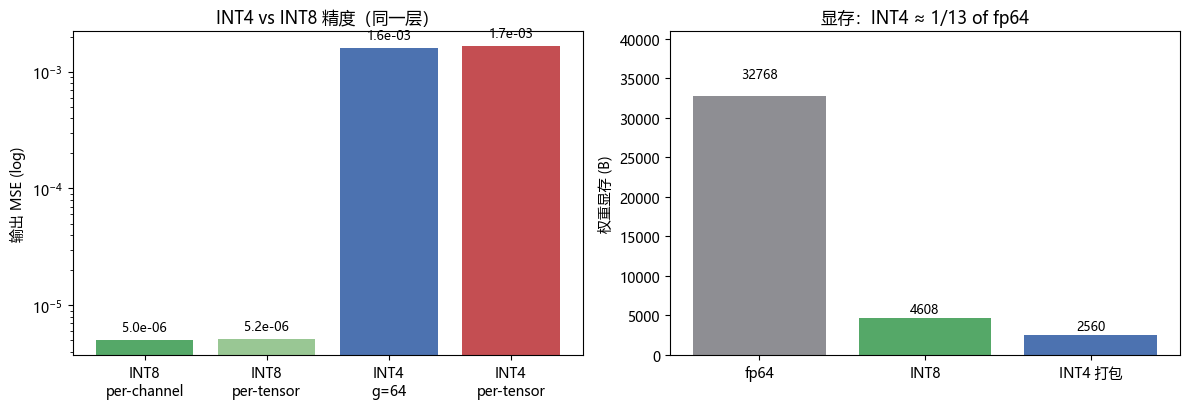

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
labels = ['INT8\nper-channel', 'INT8\nper-tensor', 'INT4\ng=64', 'INT4\nper-tensor']
vals = [m8c, m8t, m4g, m4p]
axes[0].bar(labels, vals, color=['#55A868', '#99C794', '#4C72B0', '#C44E52'])
axes[0].set_yscale('log'); axes[0].set_ylabel('输出 MSE (log)')
axes[0].set_title('INT4 vs INT8 精度（同一层）', fontsize=12)
for i, v in enumerate(vals):
    axes[0].text(i, v * 1.2, f'{v:.1e}', ha='center', fontsize=9)
mem_labels = ['fp64', 'INT8', 'INT4 打包']
mem_vals = [mem_fp, mem_i8, mem_i4]
bars = axes[1].bar(mem_labels, mem_vals, color=['#8E8E93', '#55A868', '#4C72B0'])
axes[1].set_ylabel('权重显存 (B)')
axes[1].set_title('显存：INT4 ≈ 1/13 of fp64', fontsize=12)
axes[1].set_ylim(0, max(mem_vals) * 1.25)
for b, m in zip(bars, mem_vals):
    axes[1].text(b.get_x() + b.get_width() / 2, m * 1.06, f'{m}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()


## 7. 部署：INT4 存储格式（打包 + scale 表）

生产存储格式（AWQ / GPTQ 通用）：每 $g$ 个权重一组，只存 (1) **打包 4bit 整数**（每 2 个权重 1 字节）、
(2) **每组的 scale**。加载时 $\hat W = q\cdot s$ 反量化（或直接交给低比特 GEMM 内核）。

**如实说明**：minLLM 仓库**没有**独立的 `quantization.py`——本讲与第 14 讲的手搓函数就是教学版
"部署内核"（可直接打包任意线性层权重）；真正生产走 AutoGPTQ / vLLM（GPTQ、AWQ int4）或
llama.cpp GGUF（Q4_K_M），MiniMind 部署路线同第 14 讲结论（GGUF/int8 + KV cache 量化，见第 19 讲）。


In [15]:
# ---- INT4 生产存储格式：pack / unpack（2 个 4bit 权重打包成 1 字节）----
def pack_group_int4(W, g):
    """per-group 量化后打包：返回 (packed 字节数组, scale 表, g)。"""
    out, inn = W.shape
    Wr = W.reshape(out, inn // g, g)
    scale = np.abs(Wr).max(axis=2, keepdims=True) / 7.0        # INT4 对称：±7 档
    scale = np.where(scale < 1e-12, 1.0, scale)
    q = np.clip(np.round(Wr / scale), -8, 7).astype(np.int8)   # 有符号 4bit：-8..7
    flat = q.reshape(-1)
    packed = np.zeros((flat.size + 1) // 2, dtype=np.uint8)
    n2 = flat.size // 2
    lo = (flat[0::2].astype(np.int16) & 0x0F)                  # 低 4 位
    hi = ((flat[1::2].astype(np.int16) & 0x0F) << 4)           # 高 4 位
    packed[:n2] = (lo | hi).astype(np.uint8)
    if flat.size % 2:                                          # 奇数个权重：末字节低 4 位
        packed[n2] = (flat[-1].astype(np.int16) & 0x0F).astype(np.uint8)
    return packed, scale, g

def unpack_group_int4(packed, scale, g, out, inn):
    """加载：解包 + 反量化，还原为浮点权重（或直接进低比特 GEMM）。"""
    flat = np.empty(out * inn, dtype=np.int8)
    n2 = flat.size // 2
    flat[0::2] = (packed[:n2] & 0x0F).astype(np.int8)          # 低 4 位
    flat[1::2] = ((packed[:n2] >> 4) & 0x0F).astype(np.int8)   # 高 4 位
    if flat.size % 2:
        flat[-1] = (packed[n2] & 0x0F).astype(np.int8)
    q = flat.reshape(out, inn // g, g)
    q = np.where(q >= 8, q - 16, q)                            # 4bit 有符号还原（>=8 表示负数）
    return (q * scale).reshape(out, inn)

np.random.seed(2)
Wp = np.random.randn(32, 64) * 0.5
packed, scale, g = pack_group_int4(Wp, 64)
Wr = unpack_group_int4(packed, scale, g, *Wp.shape)
diff = np.abs(Wr - quant_per_group(Wp, 64)[1]).max()
mem_p = packed.nbytes + scale.size * 8
print(f'打包后存储：{packed.nbytes} B（权重）+ {scale.size*8} B（scale）= {mem_p} B')
print(f'fp64 原始：{Wp.size*8} B → 压缩 {Wp.size*8/mem_p:.1f}×')
print(f'roundtrip 与 quant_per_group 最大偏差 = {diff:.1e}')
assert diff < 1e-9
print('pack/unpack 与直接量化完全一致 ->  PASS（存储格式正确）')


打包后存储：1024 B（权重）+ 256 B（scale）= 1280 B
fp64 原始：16384 B → 压缩 12.8×
roundtrip 与 quant_per_group 最大偏差 = 0.0e+00
pack/unpack 与直接量化完全一致 ->  PASS（存储格式正确）


## 总结

- **per-group = 粒度与开销的折衷**：g 越小误差越小，但 scale 存储从 1 个涨到 in/g 个；
  INT4 生产标配 g=64/128（本讲曲线 PASS：MSE 随 g 减小快速下降）。
- **RTN vs GPTQ**：RTN 每权重独立舍入（误差无补偿）；GPTQ 用 $H^{-1}$ 把误差沿未量化列摊还，
  再加**列重排**先量化最敏感列（本讲三方对比 PASS；随机数据增益温和，真实 LLM 权重增益数倍）。
- **INT4 vs INT8 实测**：同一层上 INT8 ≈ 5e-6、INT4 ≈ 1.6e-3 输出 MSE；显存 7.1× vs 12.8×；
  教学版"反量化回浮点"看不到速度收益——加速要靠低比特 GEMM 内核（AutoGPTQ / vLLM / llama.cpp）。
- 全链路：per-group INT4 ≈ 16× 权重压缩 + 打包存储（本讲 pack/unpack PASS）；
  再叠 KV cache 量化（第 19 讲）与 FlashAttention 就能单卡跑大模型。
